In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Air Traffic Data Cor Updated.csv',parse_dates=['Date'],index_col='Date')
df.head()

,domestic passengers,international passenegrs,domestic freight(in tonne),international freight(in tonne),GDP (in dollars),Jet Fuel Price per Gallon,Inflation Rate,Unemployement Rate
Date,,,,,,,,
2009-01-01,3288004,885435,20832,11675,1.341888e+12,71.75,10.88,7.66
2009-01-02,3293220,757168,18645,12482,1.341888e+12,61.97,10.88,7.66
2009-01-03,3122400,848046,23046,15359,1.341888e+12,65.01,10.88,7.66
2009-01-04,3266686,861715,21623,14512,1.341888e+12,68.55,10.88,7.66
2009-01-05,3883887,898410,19534,14586,1.341888e+12,72.22,10.88,7.66


In [4]:
target = ['domestic passengers']
exog = ['GDP (in dollars)', 'Jet Fuel Price per Gallon',
        'Inflation Rate ', 'Unemployement Rate']

features = target + exog

In [5]:
# Scale exogenous features
scaler_exog = MinMaxScaler()
scaled_exog = scaler_exog.fit_transform(df[exog])

# Scale targets
scaler_targets = MinMaxScaler()
scaled_targets = scaler_targets.fit_transform(df[target])

# Recombine
scaled_df = pd.DataFrame(
    np.hstack([scaled_targets, scaled_exog]),
    index=df.index,
    columns=target + exog
)

In [6]:
scaled_df

,domestic passengers,GDP (in dollars),Jet Fuel Price per Gallon,Inflation Rate,Unemployement Rate
Date,,,,,
2009-01-01,0.205462,0.0,0.092846,0.871824,0.945799
2009-01-02,0.205818,0.0,0.057348,0.871824,0.945799
2009-01-03,0.194156,0.0,0.068382,0.871824,0.945799
2009-01-04,0.204006,0.0,0.081231,0.871824,0.945799
2009-01-05,0.246142,0.0,0.094552,0.871824,0.945799
...,...,...,...,...,...
2024-01-08,0.877413,1.0,0.495046,0.187067,0.008130
2024-01-09,0.870356,1.0,0.435266,0.187067,0.008130
2024-01-10,0.913356,1.0,0.463105,0.187067,0.008130


In [ ]:

def create_sequences(data, target_col, seq_length=12):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    values = data.values
    
    for i in range(len(values) - seq_length):
        X.append(values[i:i+seq_length])        # input: seq_length months of all features
        y.append(values[i+seq_length, target_idx])  # output: next-step target
    
    return np.array(X), np.array(y)

SEQ_LEN = 12
X, y = create_sequences(scaled_df, 'domestic passengers', SEQ_LEN)

print("X shape:", X.shape)   # (samples, 12, num_features)
print("y shape:", y.shape)   # (samples,)

X shape: (180, 12, 5)
y shape: (180,)


In [8]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [9]:
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(SEQ_LEN, len(features))))
model.add(Dropout(0.2))
model.add(Dense(1))   # predict only domestic passengers

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0671 - val_loss: 0.2100
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0298 - val_loss: 0.2677
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0225 - val_loss: 0.1408
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0201 - val_loss: 0.1633
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0177 - val_loss: 0.1353
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0177 - val_loss: 0.1229
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0179 - val_loss: 0.1204
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0178 - val_loss: 0.0943
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0142 - val_loss: 0.1077
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0145 - val_loss: 0.0885
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0137 - val_loss: 0.0863
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0152 - val_loss: 0.1020
E

In [11]:
y_pred = model.predict(X_test)

# Inverse scaling
y_test_inv = scaler_targets.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler_targets.inverse_transform(y_pred)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Domestic Passengers → RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Domestic Passengers → RMSE=2078414.27, MAE=1929388.33, R²=-0.472


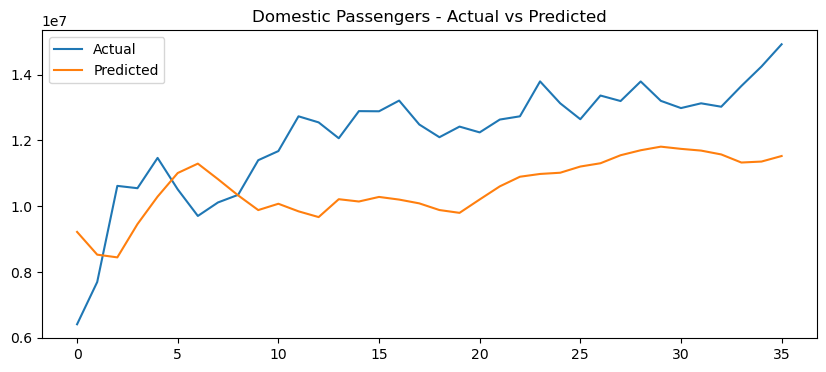

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.title("Domestic Passengers - Actual vs Predicted")
plt.legend()
plt.show()


**GRU Approach**

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout


# Build GRU model
model_gru = Sequential()
model_gru.add(GRU(32, activation='tanh', input_shape=(SEQ_LEN, len(features))))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(1))   # predict only Domestic Passengers
model_gru.compile(optimizer='RMSprop', loss='mse')
model_gru.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_17 (GRU)                    │ (None, 32)             │         3,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
# Train GRU
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0015 - val_loss: 0.0141
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0020 - val_loss: 0.0115
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0017 - val_loss: 0.0145
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0022 - val_loss: 0.0113
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0016 - val_loss: 0.0137
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0019 - val_loss: 0.0116
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0014 - val_loss: 0.0124
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0018 - val_loss: 0.0127
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0014 - val_loss: 0.0099
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0021 - val_loss: 0.0119
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0015 - val_loss: 0.0137
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0017 - val_loss: 0.0145
E

In [123]:
y_pred_gru = model_gru.predict(X_test)

# Inverse scaling
y_test_inv = scaler_targets.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler_targets.inverse_transform(y_pred_gru)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [124]:
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score , mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print(f"GRU - Domestic Passengers → RMSE={rmse:.2f}, MAE={mae:.2f},MAPE={mape:.2f}, R²={r2:.3f}")

GRU - Domestic Passengers → RMSE=1773888.62, MAE=1488263.58,MAPE=0.13, R²=-0.072


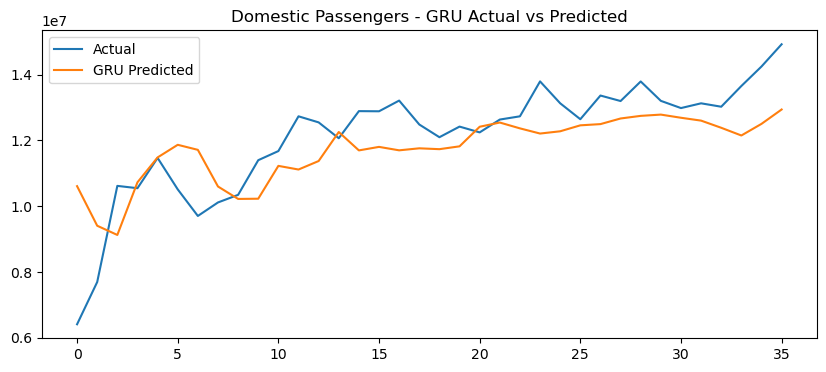

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="GRU Predicted")
plt.title("Domestic Passengers - GRU Actual vs Predicted")
plt.legend()
plt.show()


In [18]:
# Naïve baseline: predict next value as last observed value
y_naive = y_test_inv[:-1]  
baseline_rmse = np.sqrt(mean_squared_error(y_test_inv[1:], y_naive))
baseline_mae = mean_absolute_error(y_test_inv[1:], y_naive)

print(f"Naïve Baseline → RMSE={baseline_rmse:.2f}, MAE={baseline_mae:.2f}")


Naïve Baseline → RMSE=784132.25, MAE=587777.06
